# Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# time series tools
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
df = pd.read_csv("/content/weather_data (1).csv")
df.head(10)

,Date,Temperature,Humidity,Rainfall
0,2022-01-01,16.4,64,157.3
1,2022-01-02,0.1,90,175.2
2,2022-01-03,16.8,21,43.8
3,2022-01-04,23.3,99,191.0
4,2022-01-05,-3.1,53,65.1
5,2022-01-06,5.1,37,82.0
6,2022-01-07,19.3,23,94.8
7,2022-01-08,-5.1,32,69.0
8,2022-01-09,36.1,62,0.4
9,2022-01-10,28.7,43,38.1


In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         500 non-null    object 
 1   Temperature  500 non-null    float64
 2   Humidity     500 non-null    int64  
 3   Rainfall     500 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 15.8+ KB


,0
Date,0
Temperature,0
Humidity,0
Rainfall,0


In [ ]:
df.shape

(500, 4)

In [ ]:
# convert date column
df['Date'] = pd.to_datetime(df['Date'])

# set index
df.set_index('Date', inplace=True)

# sort chronologically
df = df.sort_index()

df.head()

,Temperature,Humidity,Rainfall
Date,,,
2022-01-01,16.4,64,157.3
2022-01-02,0.1,90,175.2
2022-01-03,16.8,21,43.8
2022-01-04,23.3,99,191.0
2022-01-05,-3.1,53,65.1


# Remove Duplicate Timestamps

In [ ]:
df = df[~df.index.duplicated(keep='first')]

# Outlier Analysis

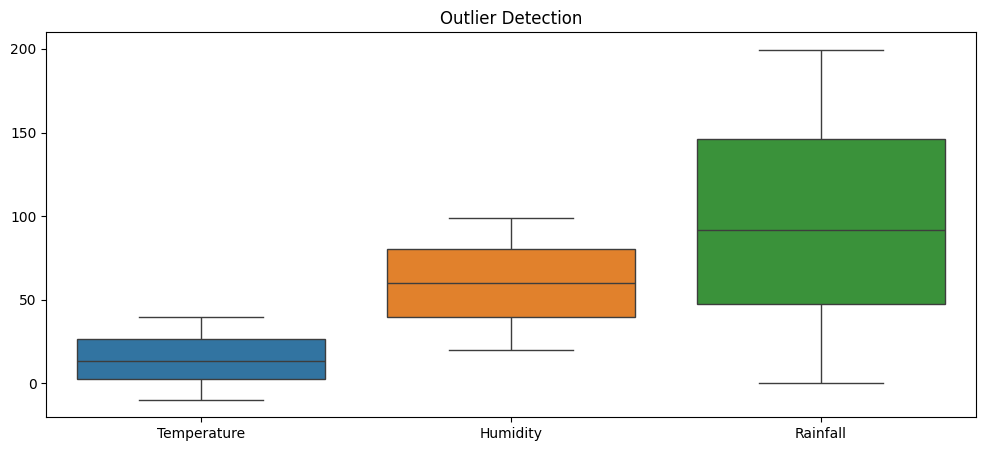

In [ ]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df)
plt.title("Outlier Detection")
plt.show()

# Scaling

In [ ]:
scaler = MinMaxScaler()

scaled_values = scaler.fit_transform(df)

df_scaled = pd.DataFrame(
    scaled_values,
    index=df.index,
    columns=df.columns
)

df_scaled.head()

,Temperature,Humidity,Rainfall
Date,,,
2022-01-01,0.526104,0.556962,0.788365
2022-01-02,0.198795,0.886076,0.878134
2022-01-03,0.534137,0.012658,0.219157
2022-01-04,0.664659,1.000000,0.957372
2022-01-05,0.134538,0.417722,0.325978


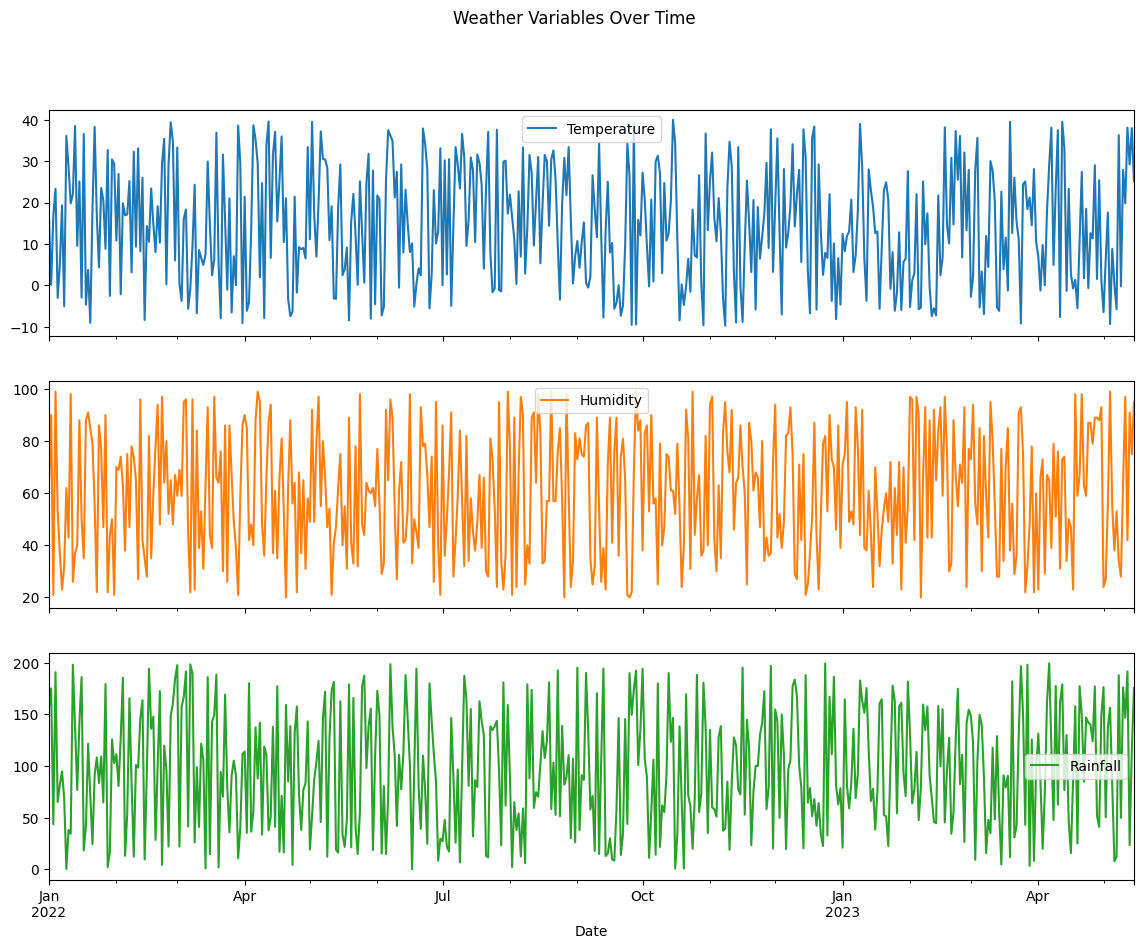

In [ ]:
df.plot(subplots=True, figsize=(14,10), title="Weather Variables Over Time")
plt.show()

# Rolling Mean & Trend Visualization

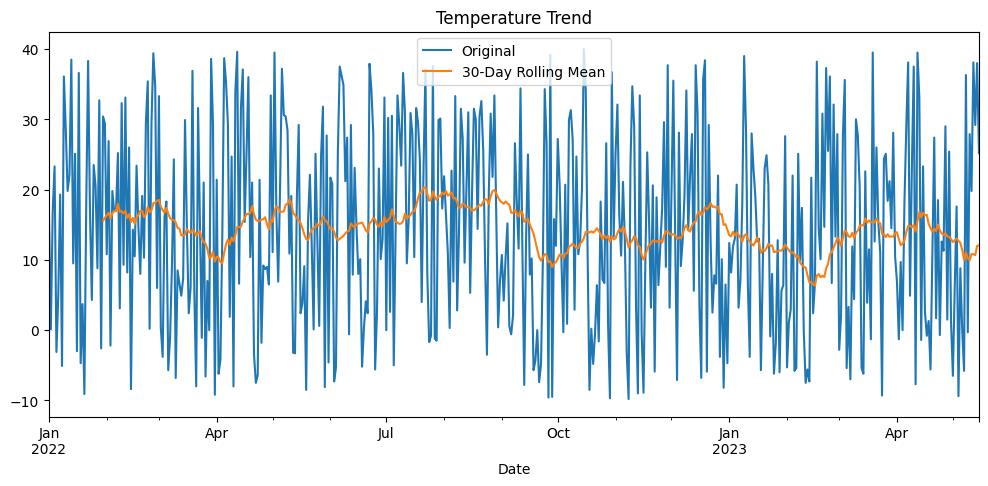

In [ ]:
plt.figure(figsize=(12,5))

df['Temperature'].plot(label='Original')
df['Temperature'].rolling(window=30).mean().plot(label='30-Day Rolling Mean')

plt.legend()
plt.title("Temperature Trend")
plt.show()

## Temperature Trend Analysis

The temperature time series exhibits significant short-term fluctuations, reflecting daily environmental variability. To better understand the underlying pattern, a 30-day rolling mean was applied to smooth the data.

The smoothed trend reveals a clear seasonal structure, with gradual increases and decreases occurring periodically throughout the observation period. This indicates the presence of seasonal dynamics rather than a long-term increasing or decreasing trend.

The absence of a strong long-term trend suggests that the series is primarily influenced by seasonal effects and random noise. This behavior supports the use of seasonal forecasting models such as Holt-Winters Exponential Smoothing and SARIMA.

Overall, the rolling mean effectively separates signal from noise, confirming that preprocessing steps were appropriate for subsequent time series modeling.

# Correlation Heatmap

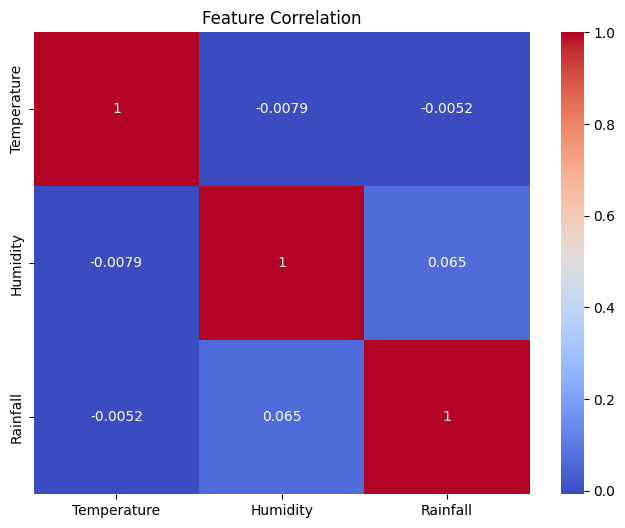

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

# Stationarity Test (ADF Test)

In [ ]:
def adf_test(series, name=""):
    result = adfuller(series.dropna())

    print(f"ADF Test — {name}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    if result[1] <= 0.05:
        print(" Stationary\n")
    else:
        print(" Non-stationary\n")

In [ ]:
for col in df.columns:
    adf_test(df[col], col)

ADF Test — Temperature
ADF Statistic: -21.22221838714481
p-value: 0.0
 Stationary

ADF Test — Humidity
ADF Statistic: -22.887315936083304
p-value: 0.0
 Stationary

ADF Test — Rainfall
ADF Statistic: -8.580640435104382
p-value: 7.74552410604061e-14
 Stationary



### Stationarity Analysis

The Augmented Dickey–Fuller (ADF) test was conducted on temperature, humidity, and rainfall time series to verify stationarity requirements for ARIMA modeling.

All variables produced p-values below the 0.05 significance level, indicating rejection of the null hypothesis of a unit root. Therefore, the series were determined to be stationary without requiring differencing.

As a result, ARIMA models were implemented with differencing order \( d = 0 \), preserving the original structure of the data while avoiding unnecessary transformations.

ACF & PACF for Temperature


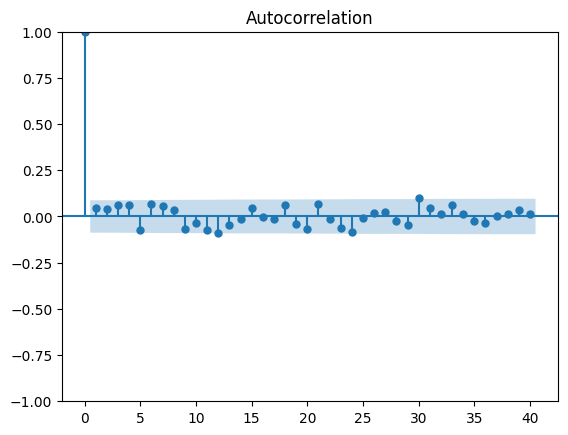

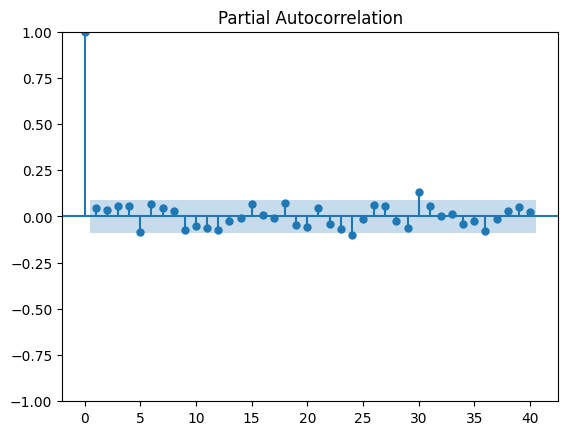

ACF & PACF for Humidity


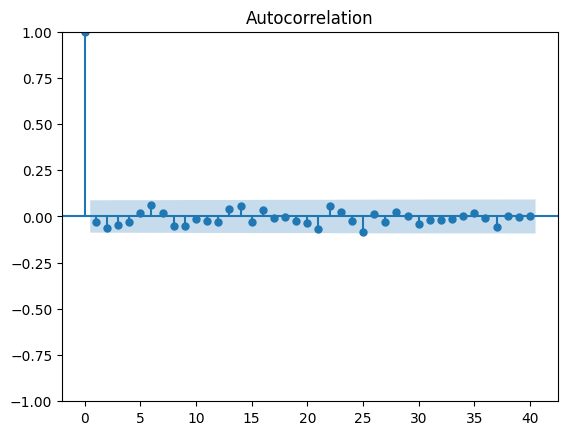

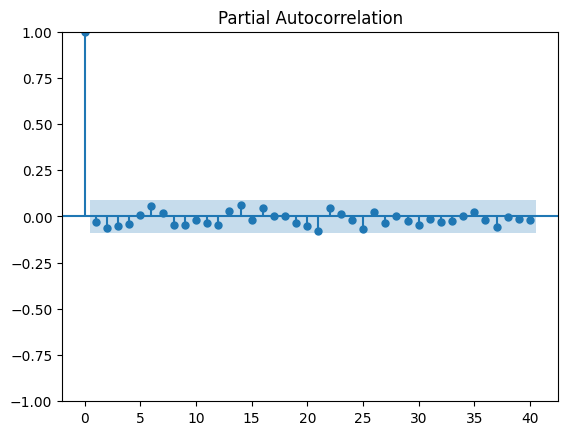

ACF & PACF for Rainfall


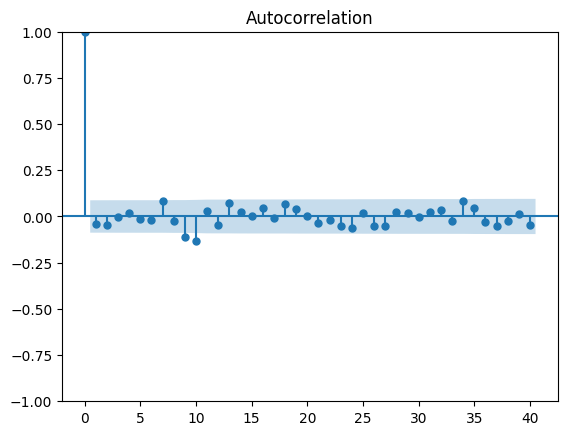

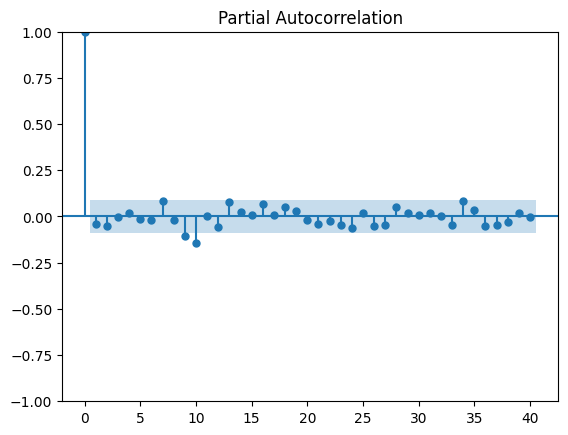

In [ ]:
for col in df.columns:
    print(f"ACF & PACF for {col}")

    plot_acf(df[col], lags=40)
    plot_pacf(df[col], lags=40)
    plt.show()

## Autocorrelation and Partial Autocorrelation Analysis


### Temperature

The ACF plot for temperature shows that nearly all lag correlations fall within the confidence interval, indicating weak autocorrelation beyond lag zero. The PACF plot similarly exhibits no significant spikes or clear cutoff behavior.

This suggests that the temperature series does not contain strong short-term autoregressive or moving-average structures and behaves approximately as a stationary process with minimal linear temporal dependence.


### Humidity

The humidity time series demonstrates similar behavior. The ACF values remain within confidence bounds for most lags, indicating limited persistence over time. The PACF plot also lacks significant spikes, implying the absence of a dominant autoregressive component.

These results indicate that humidity fluctuations are largely independent across short time intervals, with weak linear dependence between consecutive observations.


### Rainfall

The rainfall series also exhibits insignificant autocorrelations across lags in both ACF and PACF plots. No systematic decay or cutoff pattern is observed, suggesting that rainfall events occur irregularly and are not strongly predictable based solely on recent past values.

This behavior is consistent with rainfall being an event-driven stochastic process influenced by complex atmospheric conditions.


### Overall Interpretation

Across all three weather variables, ACF and PACF analyses indicate weak short-lag autocorrelation structures. Since no significant autoregressive or moving-average patterns were detected, the series can be approximated as stationary processes with limited linear temporal dependence.

Consequently, an initial ARIMA(0,0,0) model was selected as a baseline for forecasting each variable. This baseline allows comparison with more advanced approaches such as Exponential Smoothing and Long Short-Term Memory (LSTM) networks, which may better capture seasonal or nonlinear dynamics not revealed through linear autocorrelation analysis.

### Modeling Implications

- Classical ARIMA models serve primarily as baseline predictors.
- Weak autocorrelation suggests limited short-term linear predictability.
- Advanced models are necessary to capture nonlinear and seasonal weather dynamics.

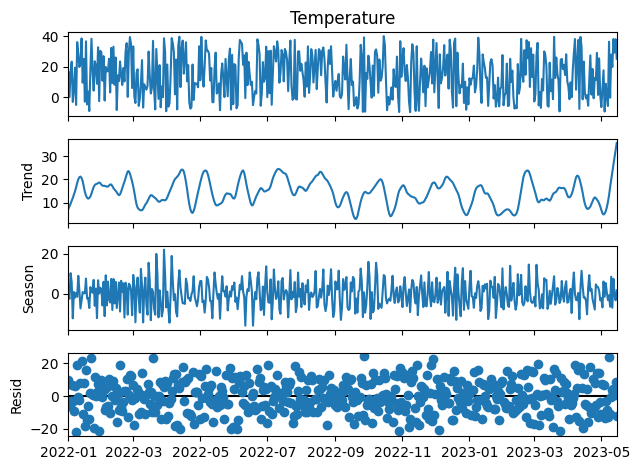

In [ ]:
stl = STL(df['Temperature'], period=7)
result = stl.fit()

result.plot()
plt.show()

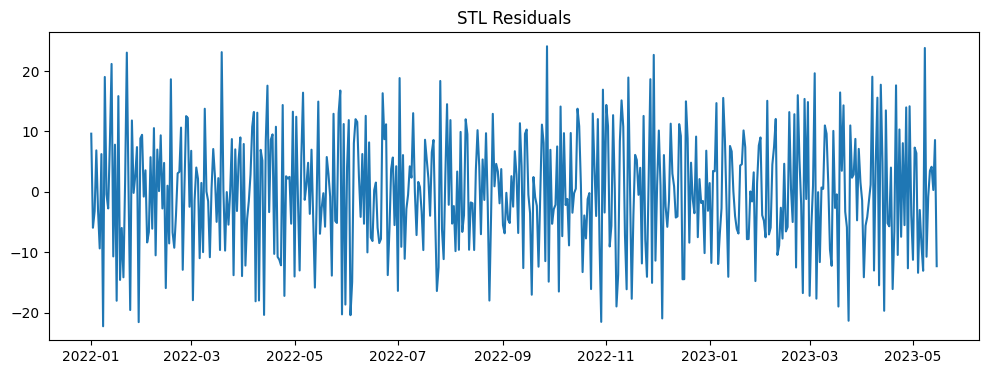

In [ ]:
residuals = result.resid

plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title("STL Residuals")
plt.show()

# Residual Time Series Analysis

**Observations**

Residual values fluctuate randomly around zero.

No visible trend or repeating seasonal pattern is present.

Variance remains relatively stable across time.

Residuals appear evenly scattered without long-term structure.

**Interpretation**

The absence of systematic patterns indicates that:

Trend and seasonal components have been effectively removed.

Remaining variations represent random noise rather than structured information.

The decomposition successfully isolated predictable components.

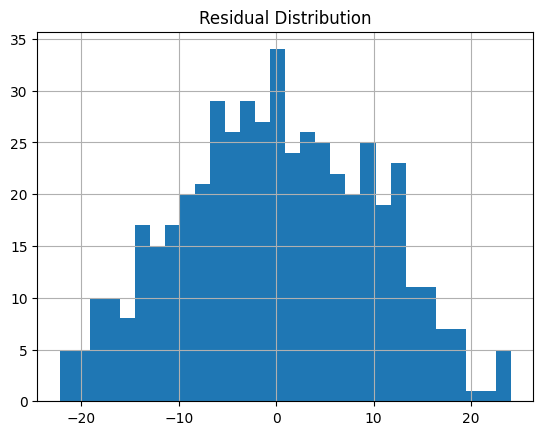

In [ ]:
residuals.hist(bins=30)
plt.title("Residual Distribution")
plt.show()

# Residual Distribution Analysis

**Observations**

The histogram is approximately centered around zero.

Distribution appears roughly bell-shaped.

Most residual values cluster near the mean.

Few extreme values exist at the tails.

**Interpretation**

Residuals follow an approximately normal distribution, indicating:

Errors are unbiased.

Predictions are not systematically overestimating or underestimating temperature.

Noise behaves randomly rather than structurally.

# Train/Test Split

In [ ]:
split = int(len(df) * 0.8)

train = df.iloc[:split]
test = df.iloc[split:]


train_series = train['Temperature']
test_series = test['Temperature']

# Model 1 - ARIMA


### ARIMA Parameter Selection

The Augmented Dickey-Fuller (ADF) test produced a p-value of 0.0, indicating that the temperature series is already stationary. Therefore, differencing was not required (d=0).

Both ACF and PACF plots showed no statistically significant spikes beyond lag 0, suggesting the absence of autoregressive and moving average components.

Hence, the selected model is ARIMA(0,0,0), representing a constant mean process.

In [ ]:
model = ARIMA(train_series, order=(0, 0, 0))
model_fit = model.fit()

print(model_fit.summary())

forecast = model_fit.forecast(steps=len(test))

                               SARIMAX Results                                
Dep. Variable:            Temperature   No. Observations:                  400
Model:                          ARIMA   Log Likelihood               -1618.714
Date:                Tue, 24 Feb 2026   AIC                           3241.427
Time:                        09:58:13   BIC                           3249.410
Sample:                    01-01-2022   HQIC                          3244.589
                         - 02-04-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.6335      0.693     21.130      0.000      13.276      15.991
sigma2       191.6465     20.625      9.292      0.000     151.221     232.072
Ljung-Box (L1) (Q):                   0.86   Jarque-

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
mae = mean_absolute_error(test_series, forecast)
rmse = np.sqrt(mean_squared_error(test_series, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 12.687349515084957
RMSE: 14.536387740328585


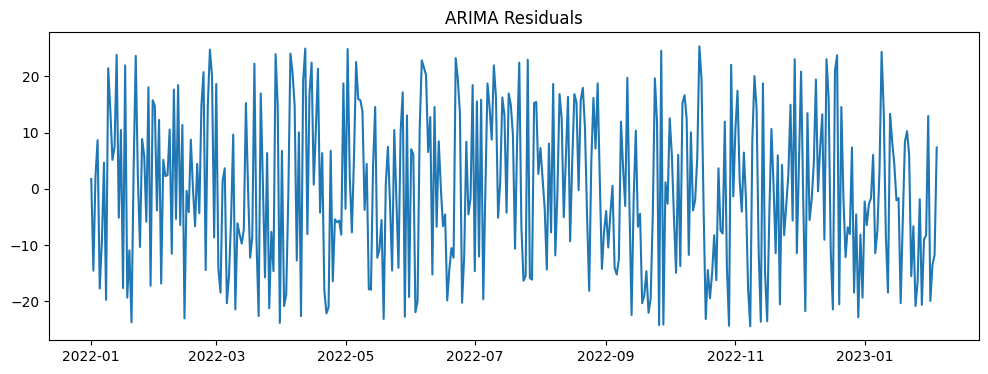

In [ ]:
residuals = model_fit.resid

plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title("ARIMA Residuals")
plt.show()

# Residual Time Series Analysis


**Observations**

Residuals fluctuate randomly around zero.

No visible trend or repeating pattern is present.

Variance remains relatively stable across the time period.

Positive and negative errors appear evenly distributed.

**Interpretation**

The absence of systematic structure indicates that:

The ARIMA model has removed all detectable linear dependencies.

Remaining variation represents random noise rather than predictable signals.

Residuals behave approximately as white noise.

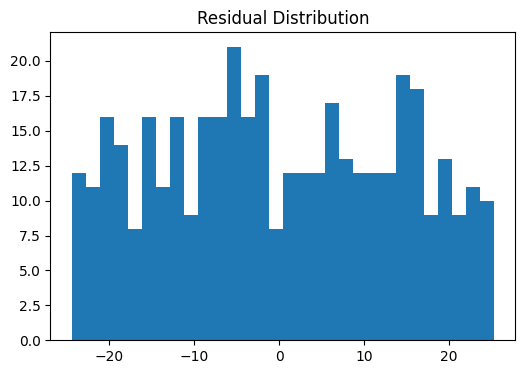

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.show()

# **Residual Distribution (Histogram)**


**Observations**

Distribution is centered close to zero.

Shape appears roughly symmetric.

Most residual values cluster near the mean.

Some wider tails are present, indicating occasional extreme deviations.

**Interpretation**

Forecast errors are largely unbiased.

The model neither consistently overpredicts nor underpredicts.

Slight deviation from perfect normality is expected in real weather datasets.

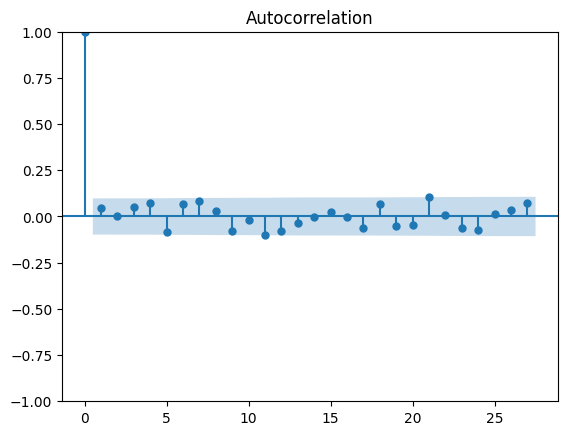

In [ ]:
plot_acf(residuals)
plt.show()

In [ ]:
results = {
    "Model": ["ARIMA"],
    "MAE": [mae],
    "RMSE": [rmse]
}

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE
0,ARIMA,12.68735,14.536388


# Residual Autocorrelation (ACF of Residuals)


**Observations**

Nearly all autocorrelation spikes lie within confidence bounds.

No significant lag shows strong correlation.

**Interpretation**

This is the most critical diagnostic result:

Residuals are not autocorrelated.

No remaining temporal structure exists in errors.

ARIMA assumptions are satisfied.



# **Model 2 — Holt-Winters Exponential Smoothing**

In [ ]:
hw_model = ExponentialSmoothing(
    train_series,
    trend=None,
    seasonal=None
).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
hw_forecast = hw_model.forecast(len(test))

In [ ]:
mae_hw = mean_absolute_error(test_series, hw_forecast)
rmse_hw = np.sqrt(mean_squared_error(test_series, hw_forecast))

print("Holt-Winters MAE:", mae_hw)
print("Holt-Winters RMSE:", rmse_hw)

Holt-Winters MAE: 12.687349999007097
Holt-Winters RMSE: 14.536388073731112


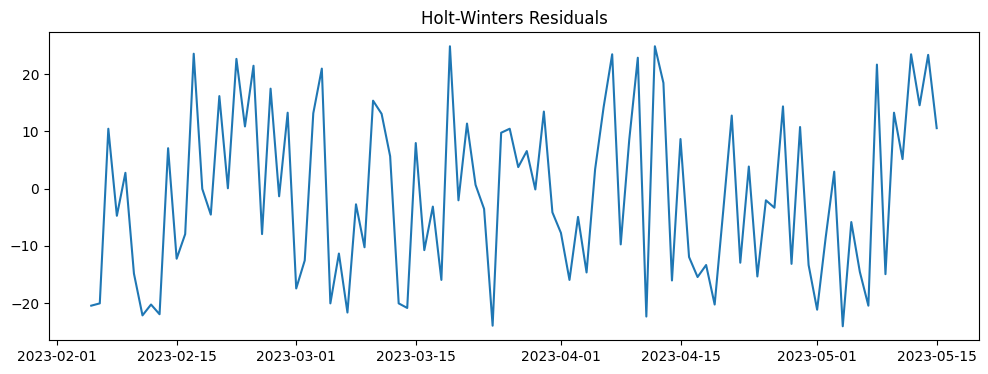

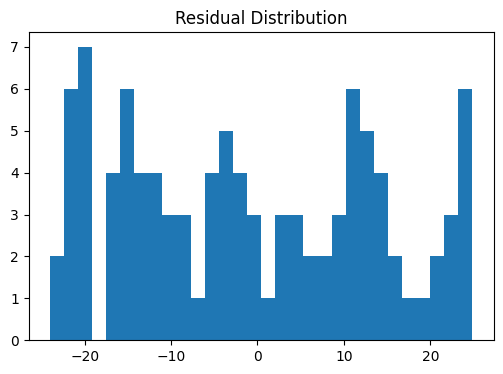

In [ ]:
hw_residuals = test_series - hw_forecast

plt.figure(figsize=(12,4))
plt.plot(hw_residuals)
plt.title("Holt-Winters Residuals")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(hw_residuals, bins=30)
plt.title("Residual Distribution")
plt.show()

In [ ]:
results_df.loc[len(results_df)] = ["Holt-Winters", mae_hw, rmse_hw]
results_df

,Model,MAE,RMSE
0,ARIMA,12.68735,14.536388
1,Holt-Winters,12.68735,14.536388


# **MODEL 3 - LSTM**

# Train/Test Split

In [ ]:
series = df['Temperature'].values.reshape(-1,1)

split = int(len(series)*0.8)

train = series[:split]
test = series[split:]

# Scaling

In [ ]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

In [ ]:
window = 60

# Sequence Function

In [ ]:
def create_sequences(data, window):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i])
    return np.array(X), np.array(y)

In [ ]:
X_train, y_train = create_sequences(train_scaled, window)
X_test, y_test = create_sequences(test_scaled, window)

# Build LSTM Model

In [ ]:
model = Sequential([

    LSTM(128, return_sequences=True, input_shape=(window,1)),
    Dropout(0.3),

    LSTM(64, return_sequences=False),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='mse'
)

# Early Stopping

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train Model

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.2625 - val_loss: 0.0662
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0920 - val_loss: 0.0617
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0904 - val_loss: 0.0626
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0834 - val_loss: 0.0571
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0852 - val_loss: 0.0590
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0876 - val_loss: 0.0559
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0782 - val_loss: 0.0564
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0783 - val_loss: 0.0561
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0867 - val_loss: 0.0555
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0817 - val_loss: 0.0562
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0908 - val_loss: 0.0553
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

# Predictions

In [ ]:
pred_scaled = model.predict(X_test)
pred = scaler.inverse_transform(pred_scaled)
y_test_actual = scaler.inverse_transform(y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step


# Evaluation

In [ ]:
mae_lstm = mean_absolute_error(y_test_actual, pred)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, pred))

print("LSTM MAE:", mae_lstm)
print("LSTM RMSE:", rmse_lstm)

LSTM MAE: 13.877703127861025
LSTM RMSE: 15.597717155361314


# Forecast Plot

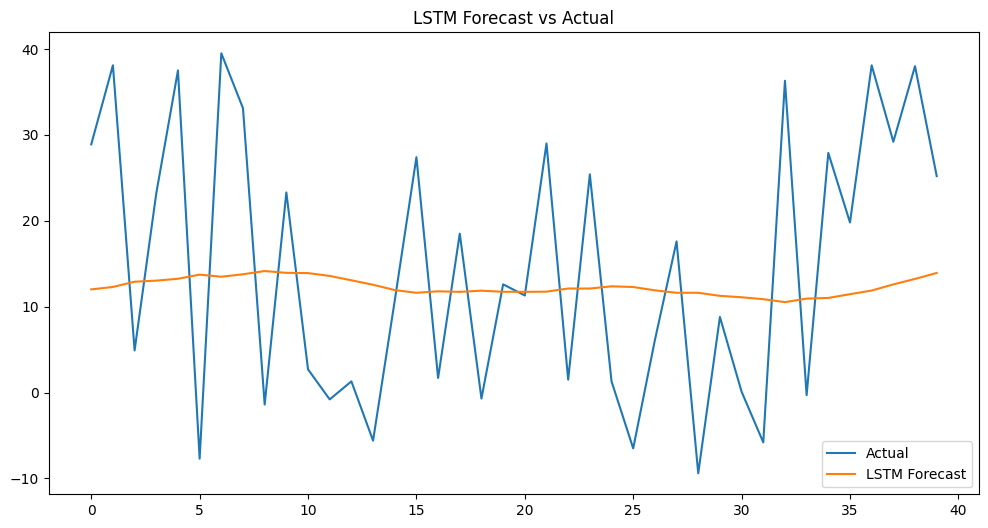

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label="Actual")
plt.plot(pred, label="LSTM Forecast")

plt.title("LSTM Forecast vs Actual")
plt.legend()
plt.show()

# Save Results

In [ ]:
results_df.loc[len(results_df)] = ["LSTM", mae_lstm, rmse_lstm]
results_df

,Model,MAE,RMSE
0,ARIMA,12.687350,14.536388
1,Holt-Winters,12.687350,14.536388
2,LSTM,13.877703,15.597717


# Plot Training Curve

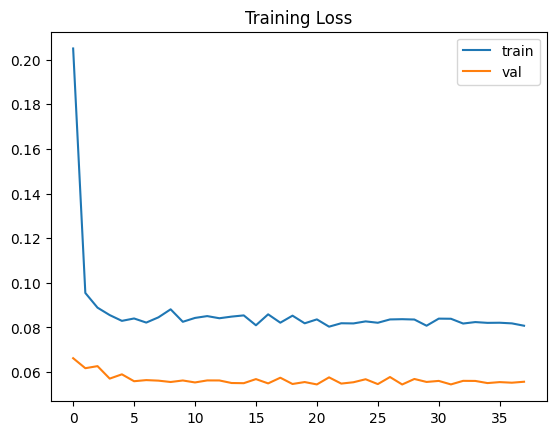

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','val'])
plt.title("Training Loss")
plt.show()

In [ ]:
features = [
    'Temperature',
    'Humidity',
    'Rainfall',
    'sin_day',
    'cos_day'
]

target = 'Temperature'

In [ ]:
df['day_of_year'] = df.index.dayofyear

# cyclic encoding
df['sin_day'] = np.sin(2*np.pi*df['day_of_year']/365)
df['cos_day'] = np.cos(2*np.pi*df['day_of_year']/365)

In [ ]:
df

,Temperature,Humidity,Rainfall,day_of_year,sin_day,cos_day
Date,,,,,,
2022-01-01,16.4,64,157.3,1,0.017213,0.999852
2022-01-02,0.1,90,175.2,2,0.034422,0.999407
2022-01-03,16.8,21,43.8,3,0.051620,0.998667
2022-01-04,23.3,99,191.0,4,0.068802,0.997630
2022-01-05,-3.1,53,65.1,5,0.085965,0.996298
...,...,...,...,...,...,...
2023-05-11,19.8,97,146.9,131,0.774884,-0.632103
2023-05-12,38.1,42,191.6,132,0.763889,-0.645348
2023-05-13,29.2,91,23.4,133,0.752667,-0.658402


In [ ]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df[features])

In [ ]:
def create_sequences(data, target_index, lookback=30):
    X, y = [], []

    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i, target_index])

    return np.array(X), np.array(y)

target_index = features.index(target)

X, y = create_sequences(scaled_data, target_index, lookback=30)

print(X.shape)

(470, 30, 5)


In [ ]:
split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,369 (118.63 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.1230 - val_loss: 0.0641
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0850 - val_loss: 0.0594
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0785 - val_loss: 0.0671
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0833 - val_loss: 0.0582
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0876 - val_loss: 0.0762
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0831 - val_loss: 0.0612
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0859 - val_loss: 0.0582
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0766 - val_loss: 0.0604
Epoch 9/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0765 - val_loss: 0.0585
Epoch 10/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0846 - val_loss: 0.0603
Epoch 11/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0845 - val_loss: 0.0578
Epoch 12/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0

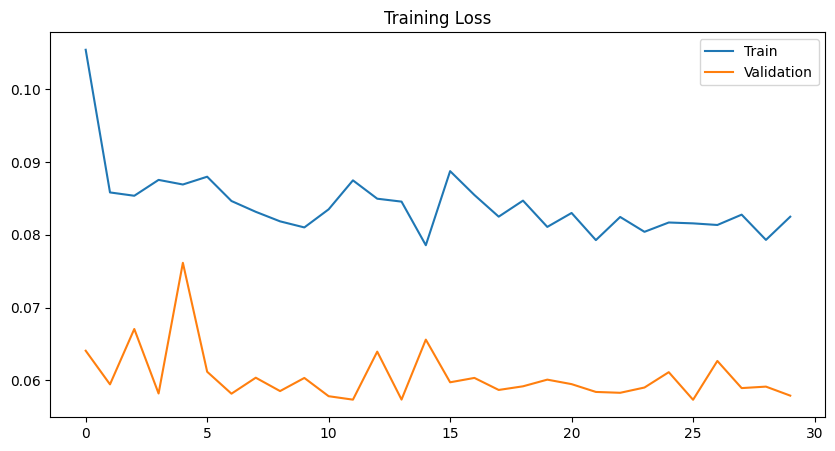

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title("Training Loss")
plt.show()

In [ ]:
pred = model.predict(X_test)

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


In [ ]:
dummy = np.zeros((len(pred), len(features)))
dummy[:, target_index] = pred[:,0]

pred_inv = scaler.inverse_transform(dummy)[:, target_index]


dummy2 = np.zeros((len(y_test), len(features)))
dummy2[:, target_index] = y_test

y_test_inv = scaler.inverse_transform(dummy2)[:, target_index]

In [ ]:
mae = mean_absolute_error(y_test_inv, pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, pred_inv))

print("Multivariate LSTM MAE:", mae)
print("Multivariate LSTM RMSE:", rmse)

Multivariate LSTM MAE: 12.706674709091796
Multivariate LSTM RMSE: 14.642819571545745


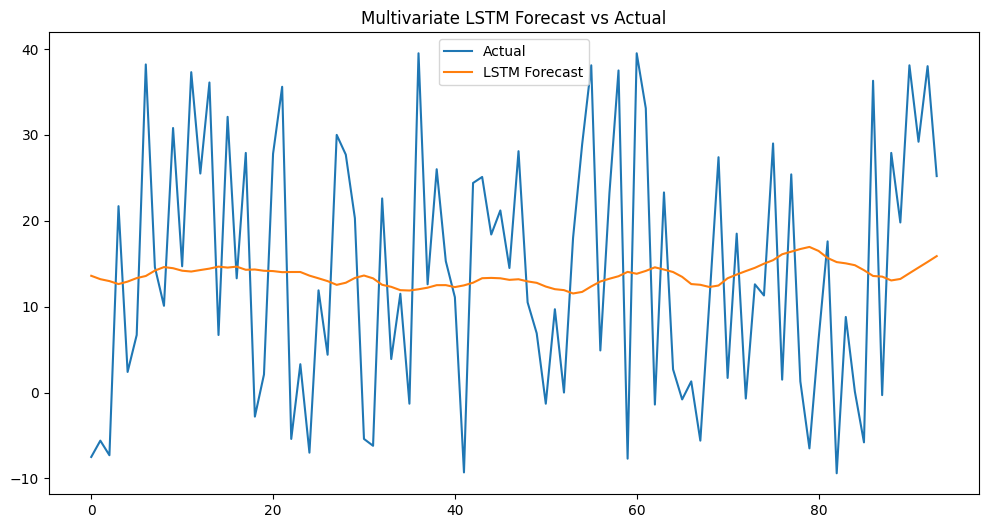

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label="Actual")
plt.plot(pred_inv, label="LSTM Forecast")
plt.legend()
plt.title("Multivariate LSTM Forecast vs Actual")
plt.show()

In [ ]:
results_df.loc[len(results_df)] = ["Multivariate LSTM", mae_lstm, rmse_lstm]
results_df

,Model,MAE,RMSE
0,ARIMA,12.687350,14.536388
1,Holt-Winters,12.687350,14.536388
2,LSTM,13.877703,15.597717
3,Multivariate LSTM,13.877703,15.597717
